1. # Analisis exploratorio del dataset fuente

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 # Proyecto HealthDemand: Análisis Exploratorio de Datos (EDA)

## 📌 Contexto del Negocio
La red de centros médicos enfrenta el desafío de optimizar la planificación de sus recursos (profesionales, consultorios y agendas). Actualmente, la gestión de la capacidad es reactiva, lo que genera desbalances operativos: saturación de agendas durante los picos de demanda y recursos subutilizados en períodos de baja afluencia. 

## 🎯 Objetivo de este Notebook
El propósito de este Análisis Exploratorio es diseccionar el historial de turnos médicos para extraer patrones de comportamiento que sirvan como base para el modelo predictivo (*Forecasting*). Específicamente, buscamos entender:
1. **Puntos de Saturación:** ¿Qué especialidades, sedes y franjas horarias concentran la mayor presión asistencial?
2. **Estacionalidad:** ¿Cómo fluctúa la demanda según el día de la semana o momento del mes?
3. **Ausentismo (No-show):** ¿Cuál es la tasa real de cancelaciones y ausencias que genera capacidad ociosa?



In [3]:
# 1. Cargar el dataset (salimos de notebooks/ y entramos a data/raw/)
ruta_csv = '../data/raw/healthdemand_buenos_aires_v2_1.csv'

In [4]:
df = pd.read_csv(ruta_csv)

In [5]:
df.head(5)

,fecha,año,mes,dia_semana,numero_dia_semana,es_feriado,barrio,nivel_socioeconomico,especialidad,turnos_disponibles,turnos_asignados,turnos_atendidos,demanda_no_atendida,cancelaciones,ausencias,tasa_ausentismo,ocupacion,nivel_saturacion,factor_temporada
0,2024-01-01,2024,1,Monday,0,True,Palermo,medio-alto,Cardiología,22,6,6,0,0,0,0.160,0.27,Bajo,0.15
1,2024-01-01,2024,1,Monday,0,True,Palermo,medio-alto,Pediatría,18,3,3,0,0,0,0.106,0.17,Bajo,0.15
2,2024-01-01,2024,1,Monday,0,True,Palermo,medio-alto,Dermatología,27,6,5,0,0,1,0.197,0.19,Bajo,0.20
3,2024-01-01,2024,1,Monday,0,True,Palermo,medio-alto,Clínica Médica,23,5,5,0,0,0,0.118,0.22,Bajo,0.15
4,2024-01-01,2024,1,Monday,0,True,Palermo,medio-alto,Traumatología,20,4,4,0,0,0,0.129,0.20,Bajo,0.15


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70010 entries, 0 to 70009
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha                 70010 non-null  str    
 1   año                   70010 non-null  int64  
 2   mes                   70010 non-null  int64  
 3   dia_semana            70010 non-null  str    
 4   numero_dia_semana     70010 non-null  int64  
 5   es_feriado            70010 non-null  bool   
 6   barrio                70010 non-null  str    
 7   nivel_socioeconomico  70010 non-null  str    
 8   especialidad          70010 non-null  str    
 9   turnos_disponibles    70010 non-null  int64  
 10  turnos_asignados      70010 non-null  int64  
 11  turnos_atendidos      70010 non-null  int64  
 12  demanda_no_atendida   70010 non-null  int64  
 13  cancelaciones         70010 non-null  int64  
 14  ausencias             70010 non-null  int64  
 15  tasa_ausentismo       70010 no

In [7]:
df['barrio'].unique()

<StringArray>
[     'Palermo',     'Recoleta',     'Belgrano',    'Caballito',
      'Almagro',       'Flores',      'La Boca', 'Villa Crespo',
        'Nuñez', 'Constitución']
Length: 10, dtype: str

In [8]:
df['nivel_socioeconomico'].unique()

<StringArray>
['medio-alto', 'alto', 'medio', 'medio-bajo', 'bajo', 'bajo-medio']
Length: 6, dtype: str

In [9]:
df['nivel_saturacion'].unique()

<StringArray>
['Bajo', 'Medio', 'Alto']
Length: 3, dtype: str

In [10]:
df['especialidad'].unique()

<StringArray>
[      'Cardiología',         'Pediatría',      'Dermatología',
    'Clínica Médica',     'Traumatología',       'Alergología',
      'Neumonología', 'Gastroenterología',        'Psicología',
      'Oftalmología',         'Urgencias']
Length: 11, dtype: str

In [11]:
# Funcion conteo y proporcion de datos
def dist(df,target):
    count= df[target].value_counts(normalize=False)
    prop = df[target].value_counts(normalize=True)*100

    dist = pd.DataFrame({'Freq[N]':count,'Prop[%]':prop.round(3)})
    return dist

In [12]:
# Ver el conteo y la proporción de Class
all_columns = df.columns.tolist()

# print(columnas_categorias)
for i in all_columns:
    print(' '*7,i.upper())
    print(dist(df,i))
    print("\n" + "*"*23 + "\n")

        FECHA
            Freq[N]  Prop[%]
fecha                       
2024-01-01      110    0.157
2024-01-02      110    0.157
2024-01-03      110    0.157
2024-01-04      110    0.157
2024-01-05      110    0.157
...             ...      ...
2025-11-30       10    0.014
2025-12-07       10    0.014
2025-12-14       10    0.014
2025-12-21       10    0.014
2025-12-28       10    0.014

[731 rows x 2 columns]

***********************

        AÑO
      Freq[N]  Prop[%]
año                   
2024    35060   50.079
2025    34950   49.921

***********************

        MES
     Freq[N]  Prop[%]
mes                  
1       6020    8.599
5       6020    8.599
7       6020    8.599
10      6020    8.599
8       5920    8.456
12      5920    8.456
3       5820    8.313
4       5800    8.285
9       5700    8.142
11      5700    8.142
6       5600    7.999
2       5470    7.813

***********************

        DIA_SEMANA
            Freq[N]  Prop[%]
dia_semana                  
Monday

In [13]:
# Esto creará una matriz para confirmar que la relación entre: dia_semana y numero_dia_semana
pd.crosstab(df['dia_semana'], df['numero_dia_semana'])

numero_dia_semana,0,1,2,3,4,5,6
dia_semana,,,,,,,
Friday,0,0,0,0,11440,0,0
Monday,11550,0,0,0,0,0,0
Saturday,0,0,0,0,0,11440,0
Sunday,0,0,0,0,0,0,1040
Thursday,0,0,0,11440,0,0,0
Tuesday,0,11550,0,0,0,0,0
Wednesday,0,0,11550,0,0,0,0


In [14]:
# Esto creará una matriz para confirmar que la relación entre: especialidad y cancelaciones
pd.crosstab(df['especialidad'], df['cancelaciones'])

cancelaciones,0,1,2,3,4,5
especialidad,,,,,,
Alergología,2390,2817,927,129,7,0
Cardiología,2667,2622,868,109,4,0
Clínica Médica,2571,2710,866,114,9,0
Dermatología,2710,2626,827,103,4,0
Gastroenterología,2618,2702,845,101,4,0
Neumonología,2542,2719,882,124,3,0
Oftalmología,2670,2647,835,115,3,0
Pediatría,2540,2714,892,116,8,0
Psicología,2655,2660,815,134,6,0


In [15]:
# Esto creará una matriz para confirmar que la relación entre: especialidad y mes
pd.crosstab(df['especialidad'], df['mes'])

mes,1,2,3,4,5,6,7,8,9,10,11,12
especialidad,,,,,,,,,,,,
Alergología,540,490,520,520,540,500,540,530,510,540,510,530
Cardiología,540,490,520,520,540,500,540,530,510,540,510,530
Clínica Médica,540,490,520,520,540,500,540,530,510,540,510,530
Dermatología,540,490,520,520,540,500,540,530,510,540,510,530
Gastroenterología,540,490,520,520,540,500,540,530,510,540,510,530
Neumonología,540,490,520,520,540,500,540,530,510,540,510,530
Oftalmología,540,490,520,520,540,500,540,530,510,540,510,530
Pediatría,540,490,520,520,540,500,540,530,510,540,510,530
Psicología,540,490,520,520,540,500,540,530,510,540,510,530


In [16]:
# Esto creará una matriz para confirmar que la relación entre: especialidad y año
pd.crosstab(df['especialidad'], df['año'])

año,2024,2025
especialidad,,
Alergología,3140,3130
Cardiología,3140,3130
Clínica Médica,3140,3130
Dermatología,3140,3130
Gastroenterología,3140,3130
Neumonología,3140,3130
Oftalmología,3140,3130
Pediatría,3140,3130
Psicología,3140,3130


In [17]:
# Esto creará una matriz para confirmar que la relación entre: turnos_atendidos y especialidad
pd.crosstab(df['turnos_atendidos'], df['especialidad'])

especialidad,Alergología,Cardiología,Clínica Médica,Dermatología,Gastroenterología,Neumonología,Oftalmología,Pediatría,Psicología,Traumatología,Urgencias
turnos_atendidos,,,,,,,,,,,
0,5,10,7,5,6,3,7,6,7,7,3
1,22,35,30,53,45,36,52,49,49,45,2
2,72,103,101,125,104,98,110,81,110,107,12
3,119,186,128,213,173,140,170,157,171,170,27
4,196,245,208,270,247,208,237,204,230,236,66
5,312,347,301,378,327,300,345,326,336,329,128
6,362,444,414,453,430,408,424,404,441,456,263
7,435,422,476,434,500,474,471,442,495,494,320
8,426,472,486,448,468,471,495,458,464,474,462


In [18]:
# 1. Ver las primeras 5 filas reales para entender el formato de los datos
print("--- Primeras 5 filas ---")
display(df.head())

--- Primeras 5 filas ---


,fecha,año,mes,dia_semana,numero_dia_semana,es_feriado,barrio,nivel_socioeconomico,especialidad,turnos_disponibles,turnos_asignados,turnos_atendidos,demanda_no_atendida,cancelaciones,ausencias,tasa_ausentismo,ocupacion,nivel_saturacion,factor_temporada
0,2024-01-01,2024,1,Monday,0,True,Palermo,medio-alto,Cardiología,22,6,6,0,0,0,0.160,0.27,Bajo,0.15
1,2024-01-01,2024,1,Monday,0,True,Palermo,medio-alto,Pediatría,18,3,3,0,0,0,0.106,0.17,Bajo,0.15
2,2024-01-01,2024,1,Monday,0,True,Palermo,medio-alto,Dermatología,27,6,5,0,0,1,0.197,0.19,Bajo,0.20
3,2024-01-01,2024,1,Monday,0,True,Palermo,medio-alto,Clínica Médica,23,5,5,0,0,0,0.118,0.22,Bajo,0.15
4,2024-01-01,2024,1,Monday,0,True,Palermo,medio-alto,Traumatología,20,4,4,0,0,0,0.129,0.20,Bajo,0.15


In [19]:
# 2. Resumen estadístico (promedios, mínimos, máximos, etc.)
print("\n--- Resumen Estadístico ---")
display(df.describe(include='all'))



--- Resumen Estadístico ---


,fecha,año,mes,dia_semana,numero_dia_semana,es_feriado,barrio,nivel_socioeconomico,especialidad,turnos_disponibles,turnos_asignados,turnos_atendidos,demanda_no_atendida,cancelaciones,ausencias,tasa_ausentismo,ocupacion,nivel_saturacion,factor_temporada
count,70010,70010.000000,70010.000000,70010,70010.000000,70010,70010,70010,70010,70010.000000,70010.000000,70010.000000,70010.000000,70010.000000,70010.000000,70010.000000,70010.000000,70010,70010.000000
unique,731,NaN,NaN,7,NaN,2,10,6,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,2024-01-01,NaN,NaN,Monday,NaN,False,Palermo,medio,Urgencias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medio,NaN
freq,110,NaN,NaN,11550,NaN,66110,7001,21003,7310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47402,NaN
mean,NaN,2024.499214,6.514212,NaN,2.544922,NaN,NaN,NaN,NaN,14.655849,12.890244,10.764234,2.822568,0.784059,1.341951,0.144190,0.742841,NaN,0.932890
std,NaN,0.500003,3.451586,NaN,1.747381,NaN,NaN,NaN,NaN,5.316080,5.812765,4.564439,4.527730,0.760340,1.213463,0.061016,0.183817,NaN,0.270854
min,NaN,2024.000000,1.000000,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.050000,0.000000,NaN,0.150000
25%,NaN,2024.000000,4.000000,NaN,1.000000,NaN,NaN,NaN,NaN,11.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.100000,0.670000,NaN,0.780000
50%,NaN,2024.000000,7.000000,NaN,3.000000,NaN,NaN,NaN,NaN,15.000000,13.000000,11.000000,1.000000,1.000000,1.000000,0.134000,0.790000,NaN,1.000000
75%,NaN,2025.000000,10.000000,NaN,4.000000,NaN,NaN,NaN,NaN,18.000000,17.000000,14.000000,4.000000,1.000000,2.000000,0.181000,0.860000,NaN,1.000000


In [20]:
# 3. ¿Tenemos datos faltantes o nulos? (Crucial para saber si hay que limpiar)
nulos = df.isnull().sum()
print("\n--- Valores Nulos por Columna ---")
print(nulos[nulos > 0] if nulos.sum() > 0 else "¡Excelente! No hay valores nulos, el dataset está limpio.")



--- Valores Nulos por Columna ---
¡Excelente! No hay valores nulos, el dataset está limpio.


In [21]:
# ==============================================================================
# 1. CONFIGURACIÓN DE COLUMNAS
# ==============================================================================
col_especialidad = 'especialidad'
col_estado = 'cancelaciones'
col_dia = 'dia_semana'
col_horario = 'mes'
col_sede = 'barrio'

In [22]:
# Configuración visual profesional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

C:\Users\marvi\AppData\Local\Temp\ipykernel_22096\774777306.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_especialidades.values, y=top_especialidades.index, palette="viridis")


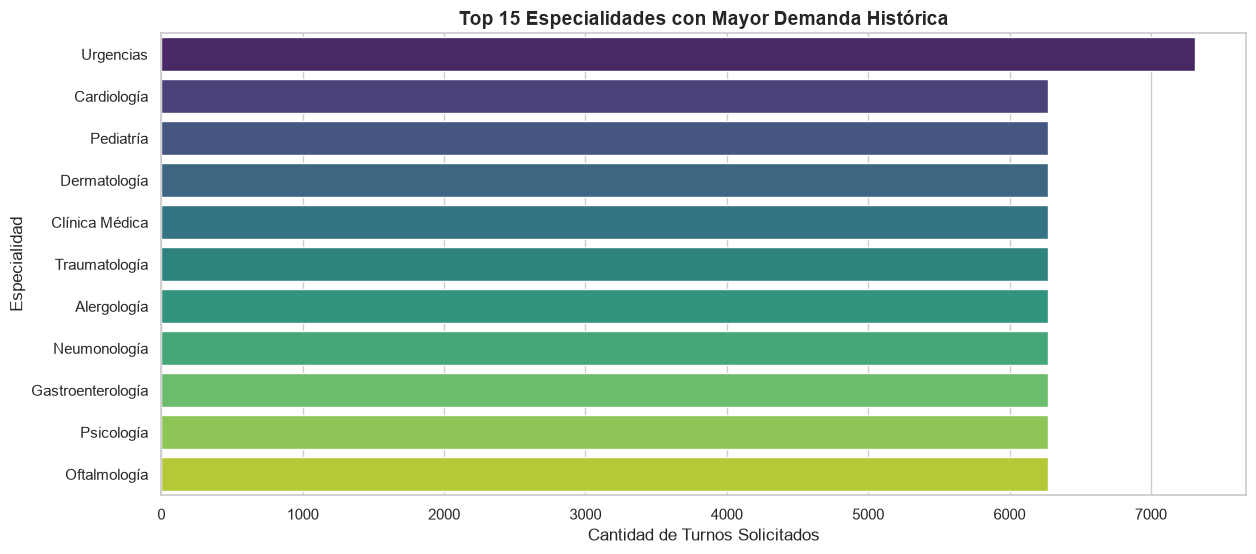

In [23]:
# ==============================================================================
# 2. GRÁFICOS DE NEGOCIO PARA HEALTHDEMAND
# ==============================================================================

# Gráfico A: Demanda por Especialidad (Top 15) - ¿Dónde concentramos recursos?
plt.figure(figsize=(14, 6))
top_especialidades = df[col_especialidad].value_counts().head(15)
sns.barplot(x=top_especialidades.values, y=top_especialidades.index, palette="viridis")
plt.title('Top 15 Especialidades con Mayor Demanda Histórica', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Turnos Solicitados')
plt.ylabel('Especialidad')
plt.show()



**Urgencias** destaca como el área con mayor volumen histórico (superando los 7,300 registros), despegándose del resto de las especialidades que mantienen una línea base nivelada (aprox. 6,270 turnos cada una). Este comportamiento es altamente coherente con la realidad operativa, donde la demanda espontánea suele superar a la programada. El modelo predictivo deberá aislar el comportamiento de "Urgencias", ya que sus picos de saturación responderán a factores más volátiles (como estacionalidad o días de la semana) y no a la disponibilidad de una agenda estándar.

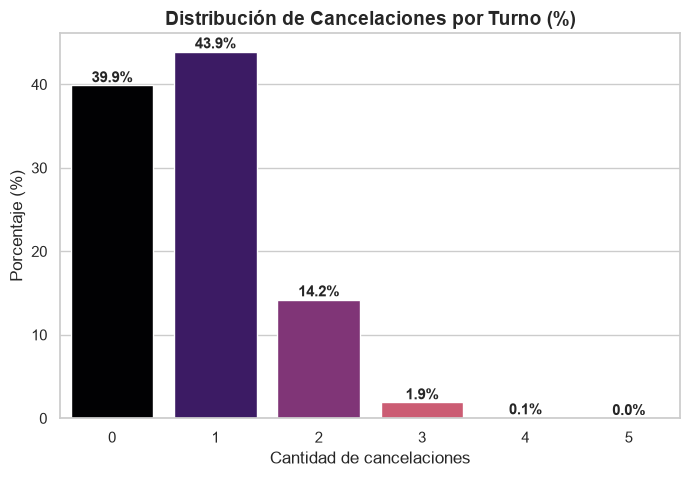

In [24]:
# Gráfico B: Análisis de cancelaciones - ¿Cuánta capacidad se desperdicia?
plt.figure(figsize=(8, 5))
cancelaciones = df[col_estado].value_counts(normalize=True).sort_index() * 100
ax = sns.barplot(x=cancelaciones.index, y=cancelaciones.values, hue=cancelaciones.index, palette="magma", legend=False)
plt.title('Distribución de Cancelaciones por Turno (%)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de cancelaciones')
plt.ylabel('Porcentaje (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()

**📌 Interpretación: Impacto de las Cancelaciones (Dataset)**
La actualización de los datos revela una realidad operativa aún más crítica: **el 60.1% de los bloques operativos presenta al menos una cancelación**, siendo el escenario de "1 cancelación exacta" el más frecuente de toda la red (43.9%). Además, la cola de la distribución nos muestra casos extremos de hasta 4 y 5 cancelaciones para un mismo turno. Esta inestabilidad generalizada confirma de manera definitiva que planificar con promedios estáticos es ineficiente. El futuro modelo predictivo será clave para encontrar qué variables (ej. Urgencias vs. Programados, o el nivel de saturación) están disparando este nivel de ausentismo.

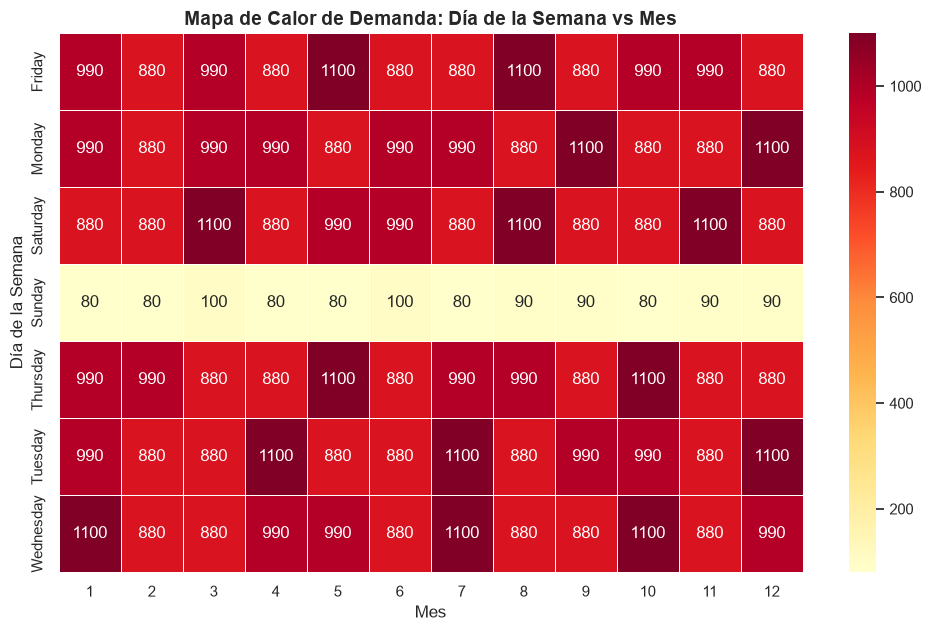

In [25]:
# Gráfico C: Mapa de calor (día vs mes) - Identificación de picos de demanda
plt.figure(figsize=(12, 7))
# Creamos una tabla cruzada contando la cantidad de turnos
heatmap_data = pd.crosstab(df[col_dia], df[col_horario])
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt="d", linewidths=.5)
plt.title('Mapa de Calor de Demanda: Día de la Semana vs Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Día de la Semana')
plt.show()

**📌 Interpretación: Estacionalidad y el "Efecto Domingo" (Dataset)**
El nuevo mapa de calor revela un patrón operativo fundamental que no existía en la versión anterior: **la caída drástica de la actividad los días Domingo**. Mientras que de lunes a sábado el volumen de turnos se mantiene robusto y constante (entre 880 y 1,100 registros por mes), los domingos la actividad colapsa a menos de 100 registros. Esto refleja fielmente la lógica del negocio de salud, donde los domingos no hay consultorios externos programados y solo se atienden guardias. Para el modelo predictivo, la variable `dia_semana = Sunday` será un divisor categórico fundamental para no sobreestimar la predicción de demanda en los fines de semana.

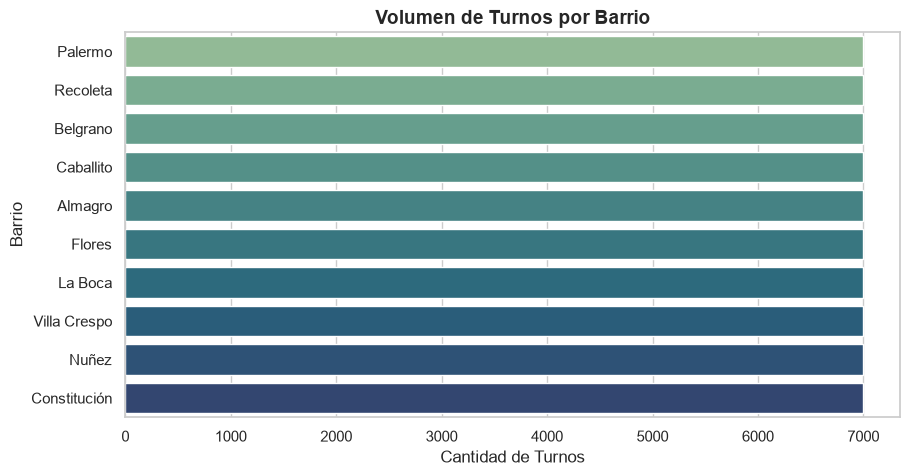

In [26]:
# Gráfico D: Distribución de demanda por barrio
plt.figure(figsize=(10, 5))
barrios = df[col_sede].value_counts()
sns.barplot(x=barrios.values, y=barrios.index, hue=barrios.index, palette="crest", legend=False)
plt.title('Volumen de Turnos por Barrio', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Turnos')
plt.ylabel('Barrio')
plt.show()

**📌 Interpretación: Distribución Geográfica (Dataset)**
A diferencia de la variable especialidades, el análisis de volumen por sede (`barrio`) en el nuevo dataset demuestra que se mantiene una distribución uniforme perfecta (exactamente 7,001 registros por sede)[cite: 8]. Este balanceo geográfico artificial ratifica que el modelo predictivo no podrá utilizar la variable "sede" de forma aislada para predecir diferencias de volumen base[cite: 8]. La saturación de una clínica dependerá estrictamente de las interacciones cruzadas (ej. Sede + Día + Especialidad) para encontrar las verdaderas variaciones de la demanda.

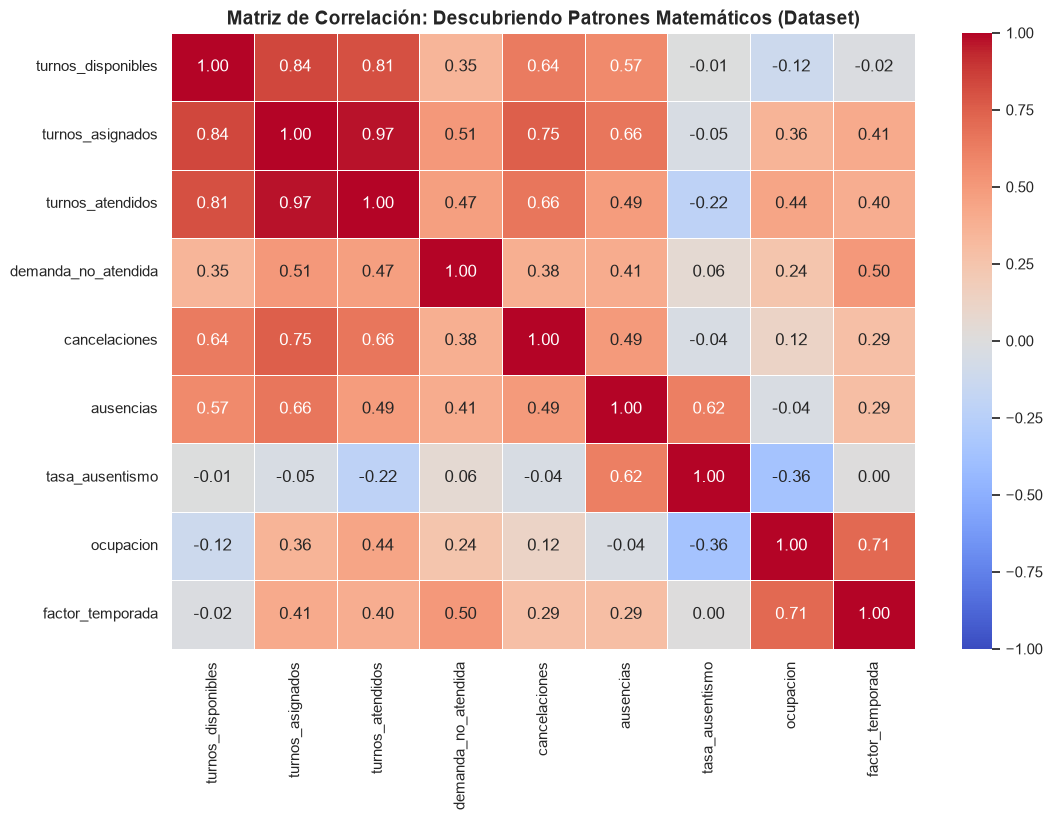

In [28]:

# Seleccionamos las columnas clave para el modelo predictivo
columnas_interes = ['turnos_disponibles', 'turnos_asignados', 'turnos_atendidos', 
                    'demanda_no_atendida', 'cancelaciones', 'ausencias', 
                    'tasa_ausentismo', 'ocupacion', 'factor_temporada']

# Calculamos la correlación de Pearson
correlacion = df[columnas_interes].corr()

# Graficamos el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(correlacion, 
            annot=True,          
            cmap='coolwarm',     
            fmt=".2f",           
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Matriz de Correlación: Descubriendo Patrones Matemáticos (Dataset)', fontsize=14, fontweight='bold')
plt.show()

**📌 Interpretación Final: Matriz de Correlación y Patrones Matemáticos**
El análisis multivariado expone los factores clave que estresan la operación diaria[cite: 9].
*   **Estacionalidad como motor:** Existe una fuerte correlación directa (0.71) entre la `ocupacion` y el `factor_temporada`, confirmando que los picos de saturación responden a las fluctuaciones anuales y no a la aleatoriedad[cite: 9].
*   **El volumen arrastra cancelaciones:** La alta correlación (0.75) entre `cancelaciones` y `turnos_asignados` demuestra que el desperdicio de capacidad aumenta de forma proporcional al tamaño de la agenda programada[cite: 9].
*   **Focos de saturación:** La `demanda_no_atendida` se vincula fuertemente tanto al `factor_temporada` (0.50) como a los `turnos_asignados` (0.51), marcando los puntos exactos donde la oferta de turnos se vuelve insuficiente ante el contexto[cite: 9].
*   **Directiva de Modelado:** Para la etapa predictiva, el modelo deberá utilizar el factor de temporada y el volumen base de turnos asignados como predictores primarios para anticipar el ausentismo general y dimensionar la futura demanda insatisfecha.

## 🚀 Próximos Pasos (Input para ETL)
Los hallazgos de este documento dictarán las reglas de limpieza, tratamiento de nulos y estandarización de categorías que se aplicarán en el pipeline de transformación (ETL).
